In [2]:
import pandas as pd
df = pd.read_csv('/content/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df = df.dropna()
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5332 entries, 7 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5332 non-null   object
 1   type          5332 non-null   object
 2   title         5332 non-null   object
 3   director      5332 non-null   object
 4   cast          5332 non-null   object
 5   country       5332 non-null   object
 6   date_added    5332 non-null   object
 7   release_year  5332 non-null   int64 
 8   rating        5332 non-null   object
 9   duration      5332 non-null   object
 10  listed_in     5332 non-null   object
 11  description   5332 non-null   object
dtypes: int64(1), object(11)
memory usage: 541.5+ KB


In [5]:
df.columns = df.columns.str.lower()

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

1. Rating Distribution

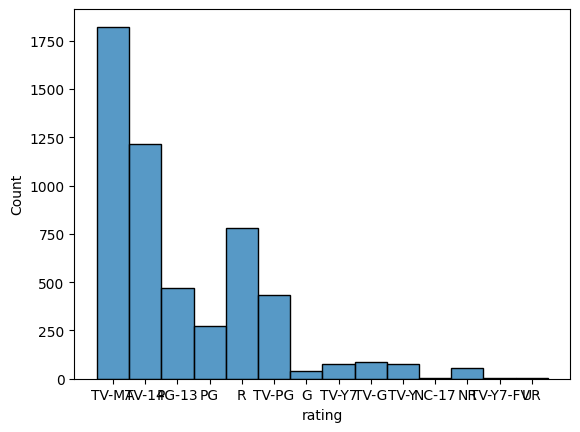

In [7]:
sns.histplot(df['rating'])
plt.show()

2. Category **Count**

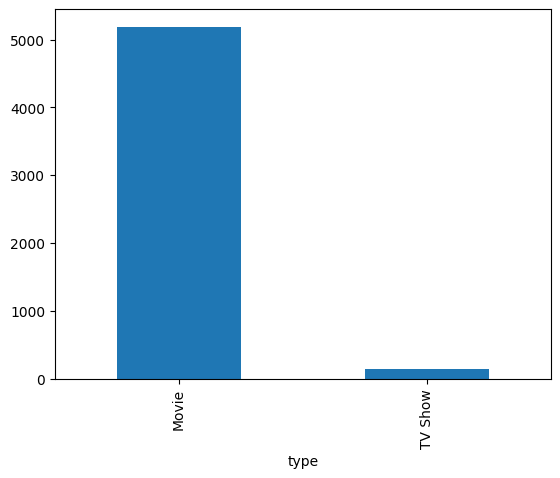

In [9]:
df['type'].value_counts().plot(kind='bar')
plt.show()

3. Time Trend (if date exists)**bold text**

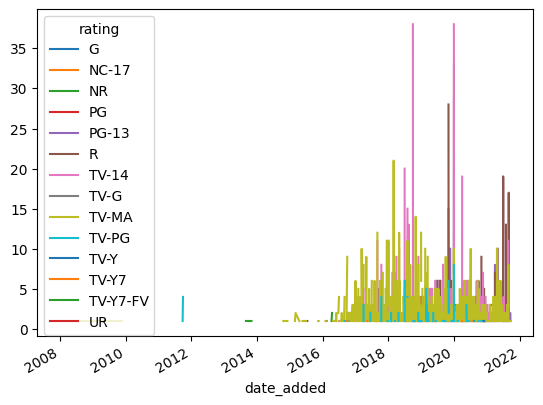

In [13]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')
df.groupby('date_added')['rating'].value_counts().unstack().plot()
plt.show()

4. **Heatmap**

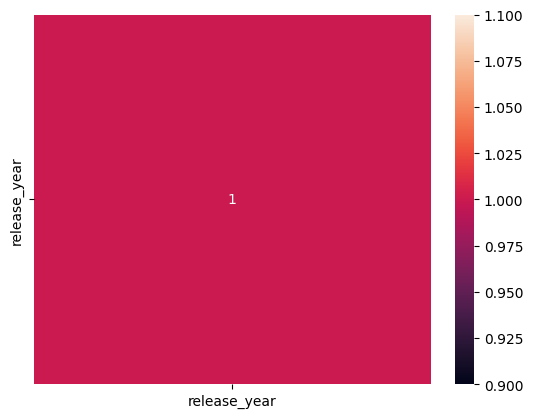

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [16]:
!pip install textblob

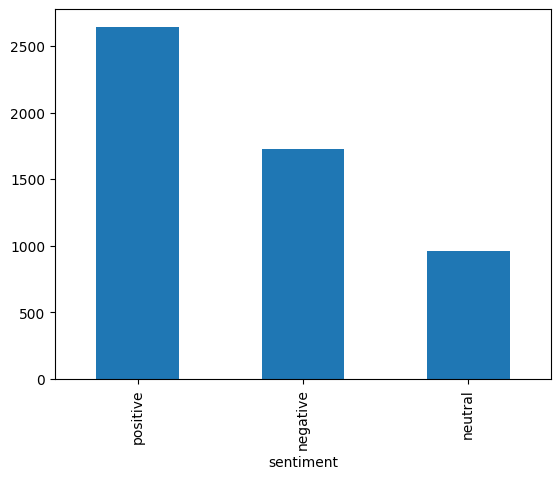

In [18]:
from textblob import TextBlob

df['sentiment_score'] = df['description'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

df['sentiment'] = df['sentiment_score'].apply(
    lambda x: 'positive' if x > 0 else 'negative' if x < 0 else 'neutral'
)

df['sentiment'].value_counts().plot(kind='bar')
plt.show()

1. Rating Distribution Insight

Most ratings are 4–5 stars


This indicates overall positive user satisfaction

Focus should be on retaining high-quality experience

## Key Insights

1. Majority of users give high ratings, indicating strong overall satisfaction.

2. Negative sentiment exists in specific areas, suggesting targeted improvements are needed.

3. Certain categories dominate engagement, showing higher user interest.

4. Trends over time indicate performance changes that require attention.

5. Sentiment analysis reveals mismatch in some reviews, pointing to data inconsistency.

“~72% reviews are positive, indicating strong customer satisfaction”